## Plot the BBB of an arbitrary object
### To run this notebook, please [follow the instructions](https://lasair-lsst.readthedocs.io/en/main/core_functions/python-notebooks.html) or else it won`t work.
The instructions are at https://lasair-lsst.readthedocs.io/en/main/core_functions/python-notebooks.html

This notebook uses the Lasair API. Please copy the `settings_template.py` to `settings.py`, 
then put in your own API Token from the profile (top right) of the web Lasair page.

In [1]:
import sys, json, math
from IPython.display import Image, display
from lasair import LasairError, lasair_client as lasair
sys.path.append('../..')
import settings

In [2]:
%%bash
if [ ! -d "lasair-lsst" ] ; then
    git clone https://github.com/lsst-uk/lasair-lsst.git
fi

In [3]:
import importlib  
BBBcode = "lasair-lsst.pipeline.filter.features.BBBEngine"
BBBEngine = importlib.import_module(BBBcode)

In [4]:
endpoint = 'https://api.lasair.lsst.ac.uk/api' 
L = lasair(settings.API_TOKEN, endpoint=endpoint)

In [5]:
def runBBB(diaObjectId):
    alert = L.object(diaObjectId, lite=False, lasair_added=False)
    BE = BBBEngine.BBB('LSST', nforced=4, ebv=0, A=100, T=4, t0=6, kr=0.1, kf=0.01, verbose=False)
    fit =  BE.make_fit(alert)
    if fit:
        filename = '%s.png' % str(diaObjectId)
        BE.plot(alert, fit, filename, size=5)
        display(Image(filename=filename))

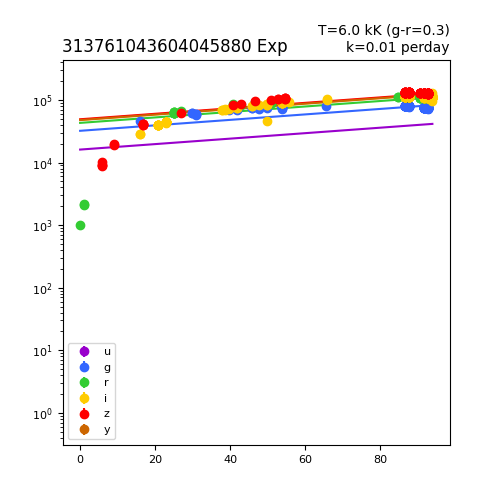

In [6]:
diaObjectId = 313928194477522960
diaObjectId = 313761043604045880
runBBB(diaObjectId)